# Default数据

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 16
slice = 16
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 32, 256, 256])
real ct:	 0.0000  51.2650  255.0000
fake mri:	 -1.0000  -0.7921  0.2317
real mri:	 -1.0000  -0.7729  1.0000
real mask:	 0.0000  0.4654  1.0000


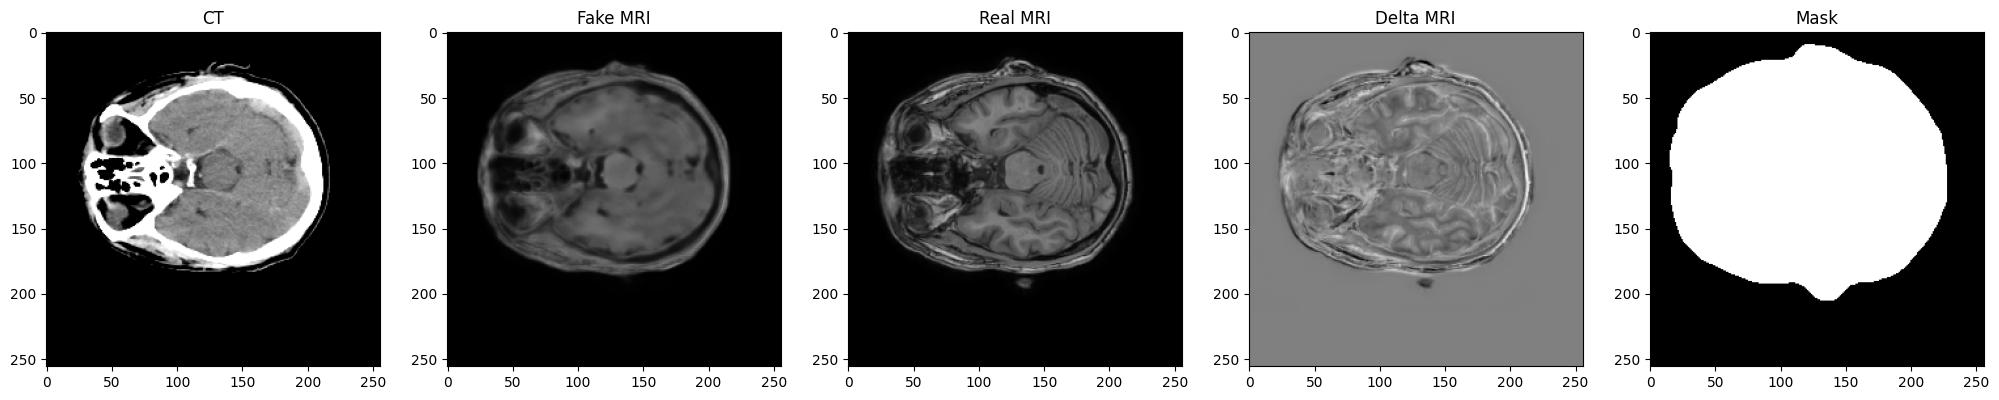

SSIM: 0.7654017210006714, PSNR: 24.067520141601562


In [9]:
real_ct_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


fake_mri.shape: torch.Size([1, 1, 32, 256, 256])
real ct:	 0.0000  39.5403  255.0000
fake mri:	 -1.0000  -0.8496  0.5252
real mri:	 -1.0000  -0.8545  1.0000
real mask:	 0.0000  0.4382  1.0000


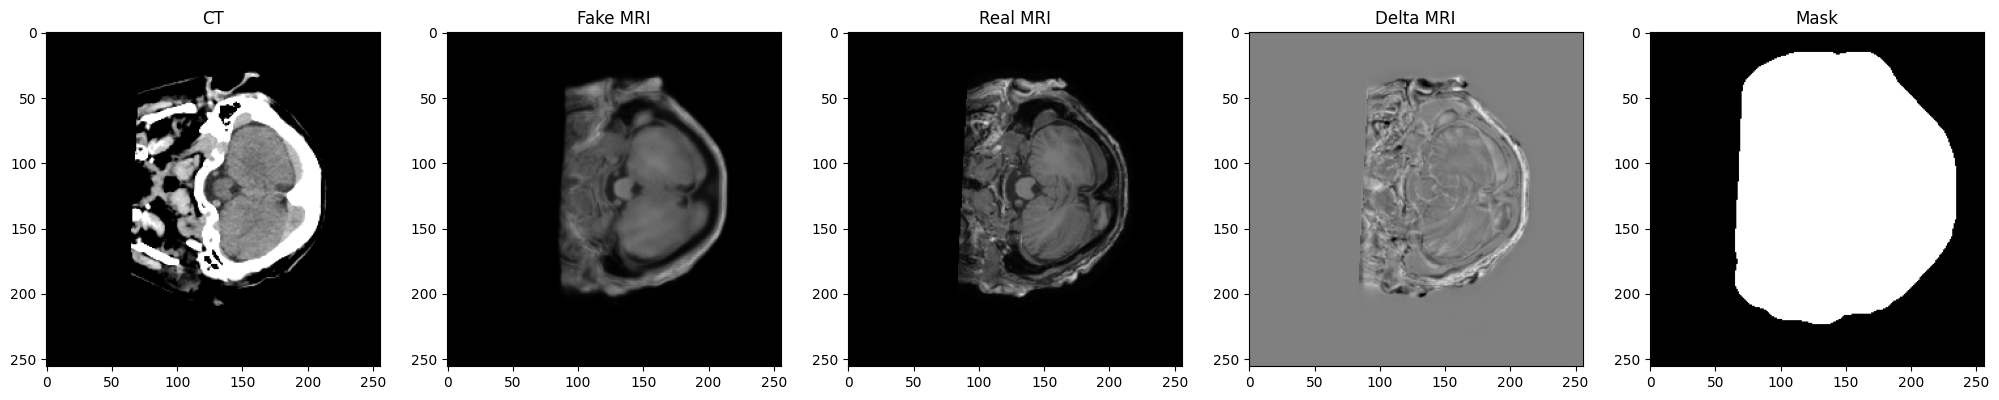

SSIM: 0.8485438823699951, PSNR: 25.31538200378418


In [10]:
real_ct_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net/sample/{epoch}_train_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


In [11]:
# 手动算fake_mri, real_mri的psnr
def get_psnr(img1, img2, data_range=2.0):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf') 
    # return 10 * torch.log10(data_range ** 2 / mse) # 原式
    return 20 * torch.log10(data_range / torch.sqrt(mse)) # 化简

print(get_psnr(fake_mri, real_mri))

tensor(25.3154)


# Liu数据

In [12]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 201
slice = 16
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 64, 256, 256])
real ct:	 0.0000  22.9786  125.0000
fake mri:	 -1.0000  -0.7992  0.7156
real mri:	 -1.0000  -0.8195  0.5608
real mask:	 1.0000  1.0000  1.0000


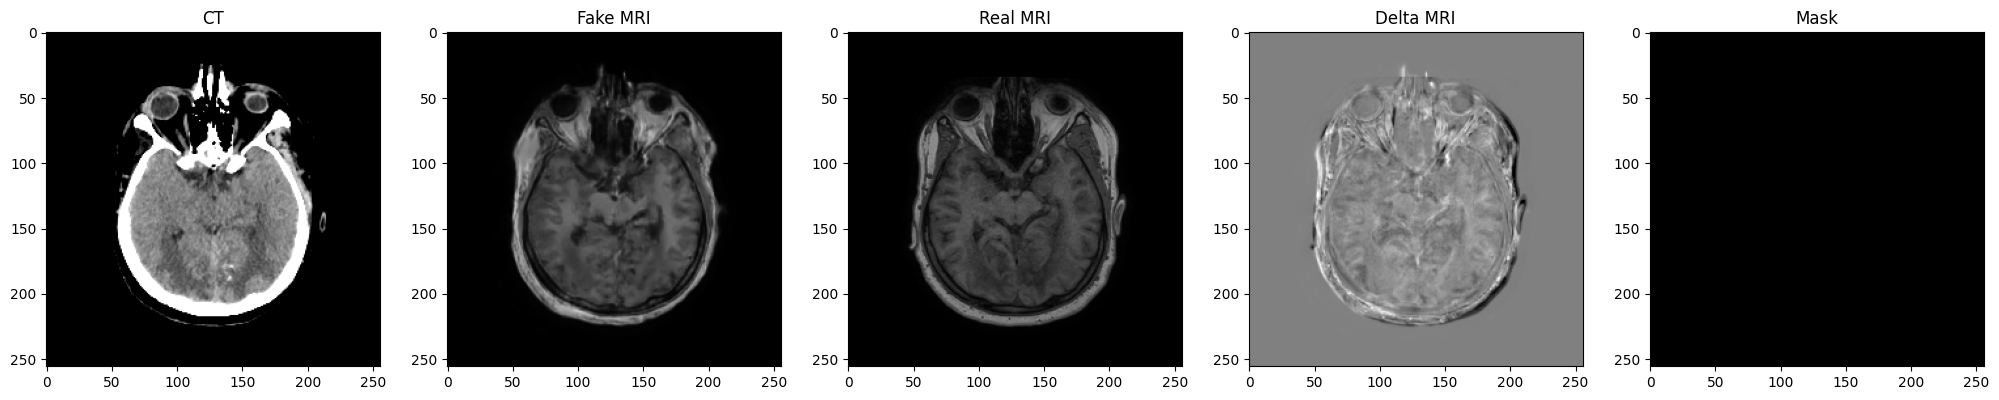

SSIM: 0.8130562901496887, PSNR: 24.128156661987305


In [13]:
real_ct_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


fake_mri.shape: torch.Size([1, 1, 64, 256, 256])
real ct:	 0.0000  28.7814  146.0000
fake mri:	 -1.0000  -0.7760  0.6912
real mri:	 -1.0000  -0.7743  0.6784
real mask:	 1.0000  1.0000  1.0000


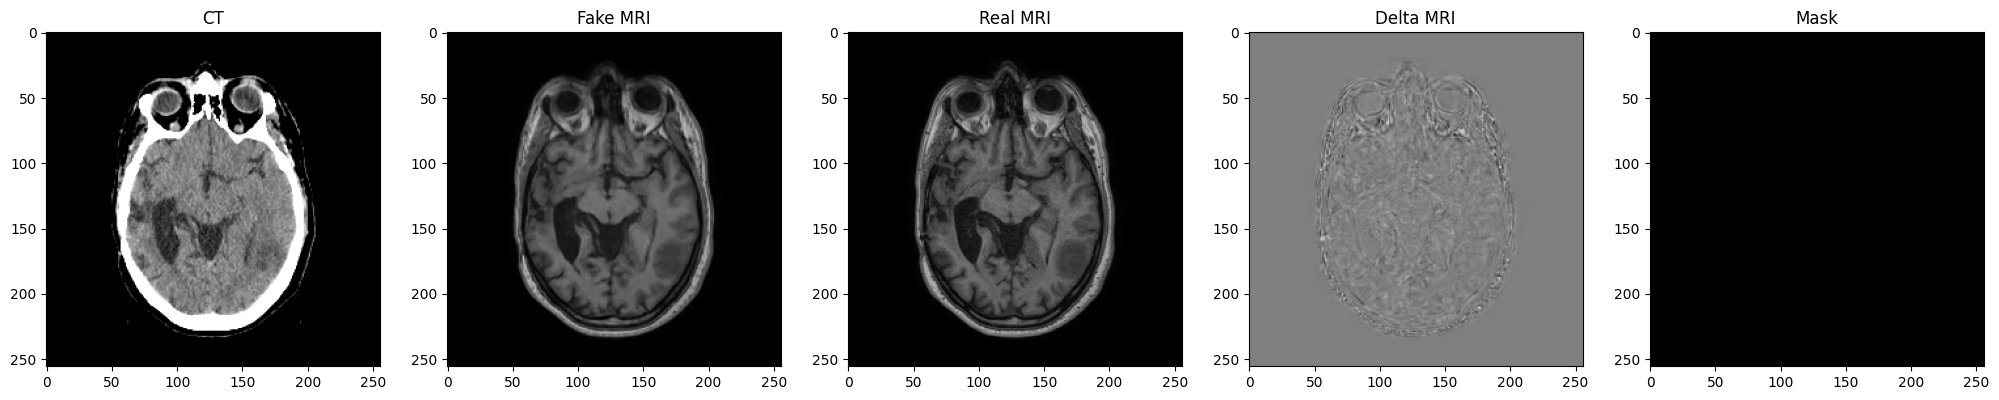

SSIM: 0.9254604578018188, PSNR: 30.777061462402344


In [14]:
real_ct_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_input.npy'
fake_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_output.npy'
real_mri_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_target.npy'
real_mask_path = f'/home/featurize/data/output/MTT-Net-LiuDataset/sample/{epoch}_train_mask.npy'

# 读取数据
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
real_mask = np.load(real_mask_path)

# 转为torch
real_ct = torch.from_numpy(real_ct).float()
fake_mri = torch.from_numpy(fake_mri).float()
real_mri = torch.from_numpy(real_mri).float()
real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# 保留4位小数
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(25, 5))
plt.subplot(151)
plt.imshow(real_ct[0, 0, slice], cmap='gray')
plt.title('CT')
plt.subplot(152)
plt.imshow(fake_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')
plt.subplot(153)
plt.imshow(real_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')
plt.subplot(154)
plt.imshow(delta_mri[0, 0, slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')
plt.subplot(155)
plt.imshow(real_mask[0, 0, slice], cmap='gray')
plt.title('Mask')
plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


# CycleGAN3D

In [7]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 51
batch_idx = 35
slice = 6
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 16, 256, 256])
fake ct:	 0.0000  24.7925  109.0000
real ct:	 0.0000  24.7925  109.0000
fake mri:	 -0.9992  -0.8550  0.8588
real mri:	 -1.0000  -0.8002  0.6784


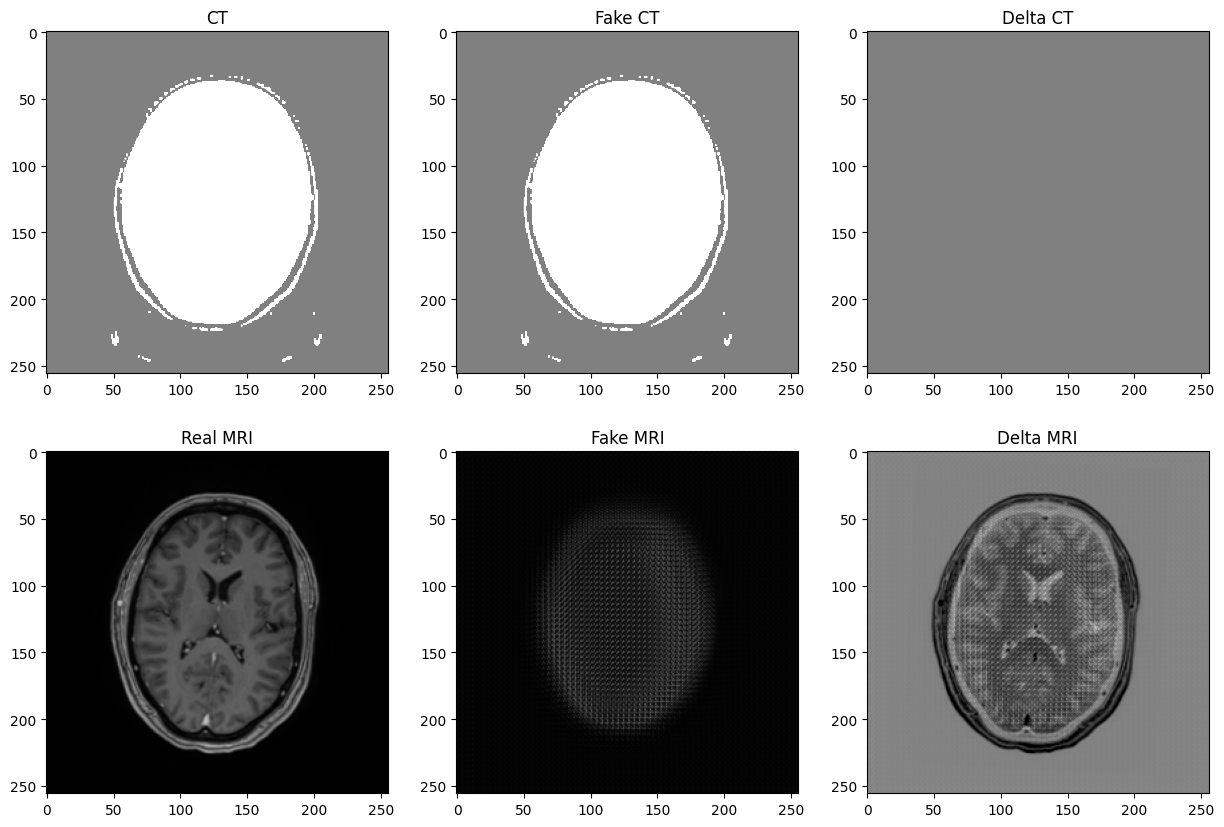

SSIM: 0.5379247069358826, PSNR: 17.475189208984375


In [9]:

real_ct_path = f'/home/featurize/data/output/CycleGAN3D/samples/real_A_{epoch}_{batch_idx}.npy'
fake_ct_path = f'/home/featurize/data/output/CycleGAN3D/samples/fake_A_{epoch}_{batch_idx}.npy'
fake_ct_path = real_ct_path # 看看原始人
real_mri_path = f'/home/featurize/data/output/CycleGAN3D/samples/real_B_{epoch}_{batch_idx}.npy'
fake_mri_path = f'/home/featurize/data/output/CycleGAN3D/samples/fake_B_{epoch}_{batch_idx}.npy'
# real_mask_path = f'/home/featurize/data/output/CycleGAN3D/samples/fake_B_{epoch}_{batch_idx}.npy'

# 读取数据
fake_ct= np.load(fake_ct_path)
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
# real_mask = np.load(real_mask_path)

# 转为torch () -> (1,1,D,H,W)
fake_ct = torch.from_numpy(fake_ct).float().unsqueeze(0).unsqueeze(0)
real_ct = torch.from_numpy(real_ct).float().unsqueeze(0).unsqueeze(0)
fake_mri = torch.from_numpy(fake_mri).float().unsqueeze(0).unsqueeze(0)
real_mri = torch.from_numpy(real_mri).float().unsqueeze(0).unsqueeze(0)
# real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri
delta_ct = fake_ct - real_ct

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# Expected `preds` and `target` to have BxCxHxW or BxCxDxHxW shape. Got preds: torch.Size([16, 256, 256]) and target: torch.Size([16, 256, 256])

# 保留4位小数
print(f'fake ct:\t {fake_ct.min():.4f}  {fake_ct.mean():.4f}  {fake_ct.max():.4f}')
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
# print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(15, 10))

plt.subplot(231)
plt.imshow(real_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('CT')

plt.subplot(232)
plt.imshow(fake_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake CT')

plt.subplot(233)
plt.imshow(delta_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta CT')

plt.subplot(234)
plt.imshow(real_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')

plt.subplot(235)
plt.imshow(fake_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')

plt.subplot(236)
plt.imshow(delta_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')

plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


In [23]:
import numpy as np
from matplotlib import pyplot as plt
import torch

# SSIM, PSNR
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.image import PeakSignalNoiseRatio as PSNR



epoch = 11
batch_idx = 10
slice = 3
data_range = 2.0 # -1~1


ssim = SSIM(data_range=data_range)
psnr = PSNR(data_range=data_range)

fake_mri.shape: torch.Size([1, 1, 16, 256, 256])
fake ct:	 -0.9923  0.1543  0.9992
real ct:	 -1.0000  -0.7785  1.0000
fake mri:	 -1.0000  -0.9282  0.8404
real mri:	 -1.0000  -0.7034  1.0000


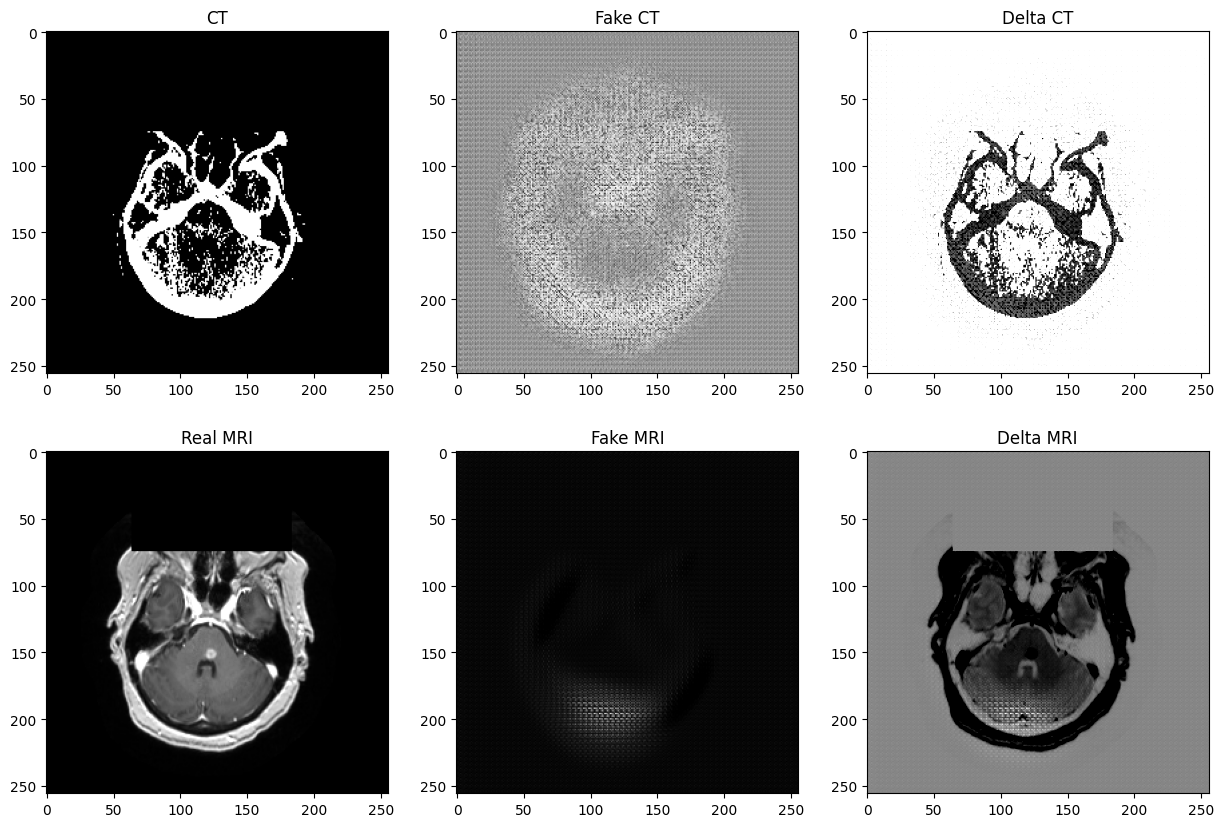

SSIM: 0.5297240614891052, PSNR: 11.335091590881348


In [24]:

real_ct_path = f'/home/featurize/data/output/NewCycleGAN3D/samples/real_A_{epoch}_{batch_idx}.npy'
fake_ct_path = f'/home/featurize/data/output/NewCycleGAN3D/samples/fake_A_{epoch}_{batch_idx}.npy'
# fake_ct_path = real_ct_path # 看看原始人
real_mri_path = f'/home/featurize/data/output/NewCycleGAN3D/samples/real_B_{epoch}_{batch_idx}.npy'
fake_mri_path = f'/home/featurize/data/output/NewCycleGAN3D/samples/fake_B_{epoch}_{batch_idx}.npy'
# real_mask_path = f'/home/featurize/data/output/CycleGAN3D/samples/fake_B_{epoch}_{batch_idx}.npy'

# 读取数据
fake_ct= np.load(fake_ct_path)
real_ct = np.load(real_ct_path)
fake_mri = np.load(fake_mri_path)
real_mri = np.load(real_mri_path)
# real_mask = np.load(real_mask_path)

# 转为torch () -> (1,1,D,H,W)
fake_ct = torch.from_numpy(fake_ct).float().unsqueeze(0).unsqueeze(0)
real_ct = torch.from_numpy(real_ct).float().unsqueeze(0).unsqueeze(0)
fake_mri = torch.from_numpy(fake_mri).float().unsqueeze(0).unsqueeze(0)
real_mri = torch.from_numpy(real_mri).float().unsqueeze(0).unsqueeze(0)
# real_mask = torch.from_numpy(real_mask).float()
delta_mri = fake_mri - real_mri
delta_ct = fake_ct - real_ct

print(f'fake_mri.shape: {fake_mri.shape}') # (1, 1, 32, 256, 256)

# Expected `preds` and `target` to have BxCxHxW or BxCxDxHxW shape. Got preds: torch.Size([16, 256, 256]) and target: torch.Size([16, 256, 256])

# 保留4位小数
print(f'fake ct:\t {fake_ct.min():.4f}  {fake_ct.mean():.4f}  {fake_ct.max():.4f}')
print(f'real ct:\t {real_ct.min():.4f}  {real_ct.mean():.4f}  {real_ct.max():.4f}')
print(f'fake mri:\t {fake_mri.min():.4f}  {fake_mri.mean():.4f}  {fake_mri.max():.4f}')
print(f'real mri:\t {real_mri.min():.4f}  {real_mri.mean():.4f}  {real_mri.max():.4f}')
# print(f'real mask:\t {real_mask.min():.4f}  {real_mask.mean():.4f}  {real_mask.max():.4f}')

# 展示Batch 0, Channel 0, Slice slice
# 设置画布（大画布）
plt.figure(figsize=(15, 10))

plt.subplot(231)
plt.imshow(real_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('CT')

plt.subplot(232)
plt.imshow(fake_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake CT')

plt.subplot(233)
plt.imshow(delta_ct[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta CT')

plt.subplot(234)
plt.imshow(real_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Real MRI')

plt.subplot(235)
plt.imshow(fake_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Fake MRI')

plt.subplot(236)
plt.imshow(delta_mri[0,0,slice], cmap='gray', vmin=-1, vmax=1)
plt.title('Delta MRI')

plt.show()


ssim_score = ssim(fake_mri, real_mri)
psnr_score = psnr(fake_mri, real_mri)

print(f'SSIM: {ssim_score}, PSNR: {psnr_score}')


In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# 设置日志目录
log_root = '/home/featurize/data/output/MTT-Net-LiuDataset/log'

# 初始化存储数据的列表
iterations = []
train_ssim = []
eval_ssim = []

# 遍历目录中的所有JSON文件
for filename in os.listdir(log_root):
    if filename.endswith('.json'):
        try:
            # 提取迭代次数
            iter_num = int(filename.split('.')[0])
            
            # 读取JSON文件
            with open(os.path.join(log_root, filename), 'r') as f:
                data = json.load(f)
                
                # 提取SSIM指标
                if 'train_metrics' in data and 'SSIM' in data['train_metrics']:
                    train_ssim_val = data['train_metrics']['SSIM']
                else:
                    train_ssim_val = None
                
                if 'eval_metrics' in data and 'SSIM' in data['eval_metrics']:
                    eval_ssim_val = data['eval_metrics']['SSIM']
                else:
                    eval_ssim_val = None
                
                # 存储数据
                iterations.append(iter_num)
                train_ssim.append(train_ssim_val)
                eval_ssim.append(eval_ssim_val)
        except (ValueError, json.JSONDecodeError) as e:
            print(f"Error processing file {filename}: {e}")

# 将数据按迭代次数排序
sorted_indices = np.argsort(iterations)
iterations = np.array(iterations)[sorted_indices]
train_ssim = np.array(train_ssim)[sorted_indices]
eval_ssim = np.array(eval_ssim)[sorted_indices]

# 创建可视化图表
plt.figure(figsize=(12, 6))

# 绘制训练SSIM
plt.plot(iterations, train_ssim, 'b-', label='Train SSIM', marker='o', markersize=4)

# 绘制评估SSIM
plt.plot(iterations, eval_ssim, 'r-', label='Eval SSIM', marker='s', markersize=4)

# 添加图表元素
plt.title('Training and Evaluation SSIM Metrics')
plt.xlabel('Iteration')
plt.ylabel('SSIM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 自动调整x轴刻度
if len(iterations) > 0:
    max_iter = max(iterations)
    step = max(1, max_iter // 10)  # 确保至少有1步
    plt.xticks(np.arange(0, max_iter + step, step))

plt.tight_layout()
plt.show()